<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/Individual_based_model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as ns

In [14]:
#parameters

intial_population = 100
loci = 5
selection = 10
carrying_capacity = 100
optimal_trait_value = 0
optimal_growth_rate = 1.025
mutation_rate = 10**-2
generation = 1000
genotypes = np.zeros((intial_population, loci))

In [15]:
#definitions

def calculate_trait_z(individual_genotype): #i didnt define individuals how does it know what it means ?
  trait_value = np.sum(individual_genotype)
  return trait_value
trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])


def calculate_fitness(trait_values, optimal_trait_value, selection, current_population_size, carrying_capacity, optimal_growth_rate):
  trait_values = np.asarray(trait_values)

  genetic_fitness = np.exp(optimal_growth_rate * ((1 - current_population_size / carrying_capacity) - (trait_values - optimal_trait_value)**2 / (2 * selection)))

  return np.maximum(0, genetic_fitness) #why do we need to return maximum?
trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])

population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection, len(trait_values), carrying_capacity, optimal_growth_rate)


def recombine(parent1_genotype, parent2_genotype, loci): #how does it know what parent is as i didnt define it?
  """Performs 50% inheritance recombination between two parent genotypes."""
  offspring_genotype = np.zeros(loci)
  for i in range(loci): #what is i?
    if np.random.rand() < 0.5: # 50% chance to inherit from parent1
      offspring_genotype[i] = parent1_genotype[i]
    else:
      offspring_genotype[i] = parent2_genotype[i]
  return offspring_genotype

lambdas = population_fitness

offspring_counts = np.random.poisson(lambdas)


def mutate(individual, mutation_rate):
  mutated_individual = individual.copy() #what does copy do?
  mutated_loci_info = []
  for locus in range(len(individual)): #what does this do? locus, len?
    if np.random.rand() < mutation_rate:
      original_value = individual[locus]
      new_value = np.random.normal(0,1)
      mutated_individual[locus] = new_value
      mutated_loci_info.append((locus, original_value, new_value))
  return mutated_individual, mutated_loci_info

def recombine(parent1_genotype, parent2_genotype, loci):
  """Performs 50% inheritance recombination between two parent genotypes."""
  offspring_genotype = np.zeros(loci)
  for i in range(loci):
    if np.random.rand() < 0.5: # 50% chance to inherit from parent1
      offspring_genotype[i] = parent1_genotype[i]
    else:
      offspring_genotype[i] = parent2_genotype[i]
  return offspring_genotype



In [16]:
#simulation loop

fitness_history = [] # Initialize list to store fitness data for each generation
trait_value_history = [] # Initialize list to store trait value data for each generation

# Initial fitness and trait value calculation for the very first generation (before any loops)
initial_trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
current_pop_size = len(genotypes) # Initial population size
population_fitness = calculate_fitness(initial_trait_values, optimal_trait_value, selection, current_pop_size, carrying_capacity, optimal_growth_rate)
fitness_history.append(population_fitness.copy())
trait_value_history.append(initial_trait_values.copy())

for g in range(generation): #what is g?
    # Check for population extinction from the previous generation
    if len(genotypes) == 0: #wouldnt the population go extinct if fitness is 0 not genotypes?
        for _ in range(g, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # Calculate fitness for the *current* parent population to use for parent selection
    current_parent_population_size = len(genotypes);
    if current_parent_population_size == 0:
        # Population already extinct, fill remaining generations and break
        for _ in range(g, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    parent_trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
    parent_population_fitness = calculate_fitness(parent_trait_values, optimal_trait_value, selection, current_parent_population_size, carrying_capacity, optimal_growth_rate) #does the list order matter?
 # Handle case where all parents have zero fitness (extinction)
    if np.all(parent_population_fitness == 0):
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([]) # Indicate extinction for next generation
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # Prepare for parent selection
    individual_indices = np.arange(current_parent_population_size) #what does this mean?
    sum_parent_fitness = np.sum(parent_population_fitness)

    # If sum_parent_fitness is zero (due to numerical issues, etc.), treat as extinction
    if sum_parent_fitness == 0:
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([])
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    probabilities = parent_population_fitness / sum_parent_fitness
    # Determine the number of offspring to generate for the next generation.
    # In sexual reproduction, the total number of offspring for the next generation
    # is determined by the total reproductive output of the current population.
    # We use the sum of fitness values as the expected total number of offspring.
    total_offspring_to_generate = int(np.sum(parent_population_fitness)) #int?

    # If no offspring are expected, the population goes extinct
    if total_offspring_to_generate == 0:
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([])
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # --- Generate the next generation (offspring) via sexual reproduction ---
    new_gen_genotypes_list = []
    offspring_mutation_details = []
    offspring_counter = 0 #what is this?

    for _ in range(total_offspring_to_generate):
        # Select two parents based on their fitness probabilities
        chosen_parent_indices = np.random.choice(
            individual_indices,
            size=2,
            p=probabilities,
            replace=True
        )
        parent1_genotype = genotypes[chosen_parent_indices[0]]
        parent2_genotype = genotypes[chosen_parent_indices[1]]

        # Perform recombination
        offspring_genotype_recombined = recombine(parent1_genotype, parent2_genotype, loci)

        # Apply mutation
        mutated_individual, mutated_loci_info = mutate(offspring_genotype_recombined, mutation_rate)
        new_gen_genotypes_list.append(mutated_individual)

        # Print parent and offspring genotypes (for demonstration, limited to first gen, few offspring)
        if g == 0 and offspring_counter < 10: # Print for first 10 offspring in generation 0
            print(f"Gen {g}: Parent1: {parent1_genotype}, Parent2: {parent2_genotype}, Offspring: {mutated_individual}")

        if mutated_loci_info:
            offspring_mutation_details.append({
                'offspring_idx': offspring_counter,
                'parent1_idx': chosen_parent_indices[0],
                'parent2_idx': chosen_parent_indices[1],
                'mutations': mutated_loci_info
            })
        offspring_counter += 1

    # Update genotypes for the new generation
    if new_gen_genotypes_list:
        genotypes = np.array(new_gen_genotypes_list)
    else:
        genotypes = np.empty((0, loci))

    current_pop_size = len(genotypes)

     # Recalculate fitness and trait values for the *newly generated population*
    # This updated 'population_fitness' and 'trait_values' will be used as the base for the next iteration
    if current_pop_size > 0:
        trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
        population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection, current_pop_size, carrying_capacity, optimal_growth_rate)
    else:
        trait_values = np.array([])
        population_fitness = np.array([])

    fitness_history.append(population_fitness.copy())
    trait_value_history.append(trait_values.copy())


Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0.         0.         0.         0.         0.46109284]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]


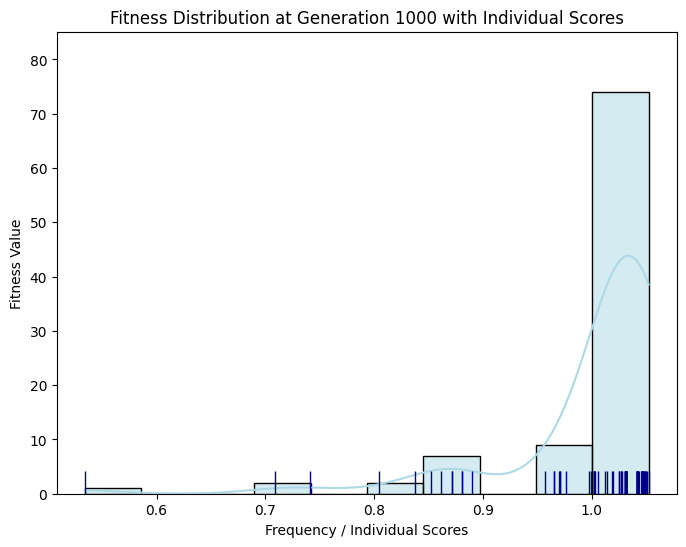

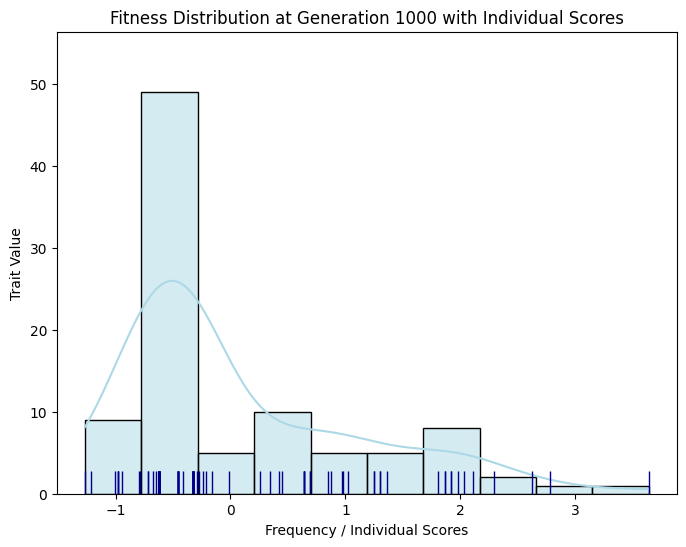

In [17]:
#graphs

final_generation_fitness = fitness_history[-1]

if len(final_generation_fitness) > 0:
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_fitness, bins=10, kde=True, color="lightblue")
    # Add rugplot to show individual fitness scores
    ns.rugplot(x=final_generation_fitness, color="darkblue", height=0.05)
    plt.title(f"Fitness Distribution at Generation {generation} with Individual Scores")
    plt.xlabel("Frequency / Individual Scores")
    plt.ylabel("Fitness Value")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No fitness data to plot.")


final_generation_trait_value = trait_value_history[-1]

if len(final_generation_trait_value) > 0:
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_trait_value, bins=10, kde=True, color="lightblue")
    # Add rugplot to show individual fitness scores
    ns.rugplot(x=final_generation_trait_value, color="darkblue", height=0.05)
    plt.title(f"Fitness Distribution at Generation {generation} with Individual Scores")
    plt.xlabel("Frequency / Individual Scores")
    plt.ylabel("Trait Value")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No fitness data to plot.")